<a href="https://colab.research.google.com/github/sachin23-an/options-pricer-greeks-iv-solver/blob/main/options_pricer_greeks_iv_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Options Pricer — Black-Scholes, Greeks, and Newton-Raphson Implied Volatility Solver



### What this notebook covers, in order
1. Black-Scholes call and put pricing, implemented from the formula
2. All four core Greeks (Delta, Gamma, Vega, Theta) implemented analytically
3. **A finite-difference cross-check** for every Greek — this is the step that proves the analytical formulas are actually correct, rather than just trusting a textbook formula was typed in right
4. A Newton-Raphson solver that recovers implied volatility from an option price
5. Sensitivity analysis — how price and Greeks change as spot, volatility, and time move
6. Real pricing examples using the actual current NIFTY 50 spot price and actual current India VIX
7. Honest conclusion and limitations

### Data policy for this notebook
This notebook uses **real, live NIFTY 50 spot price and real India VIX data**, pulled via `yfinance`, as the base inputs for all the pricing examples. There is no synthetic data anywhere in this notebook. If there's no internet access, the data cell will fail with a clear error rather than silently substituting anything fake.

**One honest limitation, stated up front:** NSE does not publish free historical per-strike option chain data (real traded option prices, real bid/ask, real open interest). Because of that, this notebook does not claim to reproduce actual traded option prices — it prices options using Black-Scholes with real spot and real VIX (as the volatility input), which is a standard, disclosed substitute, not a hidden one.


## 0. Setup and Imports

In [1]:
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 4.5)
print("Libraries loaded.")


Libraries loaded.


## 1. Data Collection — Real NIFTY 50 Spot and Real India VIX (No Fallback)

We pull the most recent NIFTY 50 closing price and the most recent India VIX value. VIX is used here as our implied volatility input, since it is India's real, published volatility index (the same standard substitution used in the other two notebooks on this CV).

**There is no synthetic fallback.** If this cell fails, there's no internet access right now — fix that and re-run.


In [2]:
import yfinance as yf

nifty_data = yf.download("^NSEI", period="5d", progress=False)["Close"]
vix_data = yf.download("^INDIAVIX", period="5d", progress=False)["Close"]

if len(nifty_data) == 0 or len(vix_data) == 0:
    raise RuntimeError(
        "Could not fetch real NIFTY 50 / India VIX data. Check your internet connection "
        "and re-run this cell — this notebook does not use synthetic data."
    )

CURRENT_SPOT = float(nifty_data.iloc[-1])
CURRENT_VIX = float(vix_data.iloc[-1])
RISK_FREE_RATE = 0.065   # approx Indian short-term risk-free rate

print(f"Real data loaded successfully.")
print(f"Latest NIFTY 50 spot: {CURRENT_SPOT:.2f}")
print(f"Latest India VIX: {CURRENT_VIX:.2f}  (used as our implied volatility input: {CURRENT_VIX/100:.4f})")


Real data loaded successfully.
Latest NIFTY 50 spot: 24570.65
Latest India VIX: 12.16  (used as our implied volatility input: 0.1216)


## 2. Black-Scholes Pricing (implemented from the formula)

Inputs: spot price `S`, strike `K`, time to expiry in years `T`, risk-free rate `r`, volatility `sigma`.


In [3]:
def bs_call_price(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_put_price(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

# quick sanity check using real spot and real VIX, a 30-day at-the-money option
T_sample = 30/365
sigma_sample = CURRENT_VIX / 100
call_sample = bs_call_price(CURRENT_SPOT, CURRENT_SPOT, T_sample, RISK_FREE_RATE, sigma_sample)
put_sample = bs_put_price(CURRENT_SPOT, CURRENT_SPOT, T_sample, RISK_FREE_RATE, sigma_sample)
print(f"30-day ATM call price: {call_sample:.2f}")
print(f"30-day ATM put price:  {put_sample:.2f}")


30-day ATM call price: 410.25
30-day ATM put price:  279.33


## 3. The Greeks — Implemented Analytically

Each Greek measures how the option's price is expected to change when one input moves, holding everything else constant:

| Greek | Measures sensitivity to |
|---|---|
| Delta | Spot price |
| Gamma | Rate of change of Delta itself (i.e. how curved the payoff is) |
| Vega | Volatility |
| Theta | Time (i.e. time decay — how much value is lost per day) |
| Rho | Interest rate |


In [4]:
def d1_d2(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return d1, d2

def greeks_call(S, K, T, r, sigma):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T)
    theta = (-(S * norm.pdf(d1) * sigma) / (2*np.sqrt(T))
             - r * K * np.exp(-r*T) * norm.cdf(d2))
    rho   = K * T * np.exp(-r*T) * norm.cdf(d2)
    return {"Delta": delta, "Gamma": gamma, "Vega": vega, "Theta": theta, "Rho": rho}

def greeks_put(S, K, T, r, sigma):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    delta = norm.cdf(d1) - 1
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T)
    theta = (-(S * norm.pdf(d1) * sigma) / (2*np.sqrt(T))
             + r * K * np.exp(-r*T) * norm.cdf(-d2))
    rho   = -K * T * np.exp(-r*T) * norm.cdf(-d2)
    return {"Delta": delta, "Gamma": gamma, "Vega": vega, "Theta": theta, "Rho": rho}

call_greeks_sample = greeks_call(CURRENT_SPOT, CURRENT_SPOT, T_sample, RISK_FREE_RATE, sigma_sample)
put_greeks_sample = greeks_put(CURRENT_SPOT, CURRENT_SPOT, T_sample, RISK_FREE_RATE, sigma_sample)

print("30-day ATM Call Greeks:")
for k, v in call_greeks_sample.items():
    print(f"  {k}: {v:.4f}")

print("\n30-day ATM Put Greeks:")
for k, v in put_greeks_sample.items():
    print(f"  {k}: {v:.4f}")


30-day ATM Call Greeks:
  Delta: 0.5678
  Gamma: 0.0005
  Vega: 2769.5880
  Theta: -2928.8583
  Rho: 1112.8789

30-day ATM Put Greeks:
  Delta: -0.4322
  Gamma: 0.0005
  Vega: 2769.5880
  Theta: -1340.2756
  Rho: -895.8662


## 4. Finite-Difference Cross-Check — Proving the Analytical Greeks Are Actually Correct

This is the step most option-pricer tutorials skip. Instead of just trusting that the analytical formula above was typed in correctly, we independently compute each Greek numerically — by nudging one input slightly and measuring how much the price actually changes — and compare the two. If they don't match closely, something is wrong with the analytical formula.

This is a real, standard validation technique (not unique to this notebook), and it's included here because "does the code actually do what the formula says" is exactly the kind of question an interviewer would ask.


In [5]:
def finite_difference_delta(S, K, T, r, sigma, option_type="call", eps=1.0):
    price_fn = bs_call_price if option_type == "call" else bs_put_price
    return (price_fn(S+eps, K, T, r, sigma) - price_fn(S-eps, K, T, r, sigma)) / (2*eps)

def finite_difference_gamma(S, K, T, r, sigma, option_type="call", eps=1.0):
    price_fn = bs_call_price if option_type == "call" else bs_put_price
    return (price_fn(S+eps, K, T, r, sigma) - 2*price_fn(S, K, T, r, sigma) + price_fn(S-eps, K, T, r, sigma)) / (eps**2)

def finite_difference_vega(S, K, T, r, sigma, option_type="call", eps=0.0001):
    price_fn = bs_call_price if option_type == "call" else bs_put_price
    return (price_fn(S, K, T, r, sigma+eps) - price_fn(S, K, T, r, sigma-eps)) / (2*eps)

def finite_difference_theta(S, K, T, r, sigma, option_type="call", eps=1/365):
    price_fn = bs_call_price if option_type == "call" else bs_put_price
    return -(price_fn(S, K, T+eps, r, sigma) - price_fn(S, K, T-eps, r, sigma)) / (2*eps)

comparison_rows = []
for greek_name, analytic_value, fd_func in [
    ("Delta", call_greeks_sample["Delta"], finite_difference_delta),
    ("Gamma", call_greeks_sample["Gamma"], finite_difference_gamma),
    ("Vega",  call_greeks_sample["Vega"],  finite_difference_vega),
    ("Theta", call_greeks_sample["Theta"], finite_difference_theta),
]:
    fd_value = fd_func(CURRENT_SPOT, CURRENT_SPOT, T_sample, RISK_FREE_RATE, sigma_sample, "call")
    comparison_rows.append({
        "Greek": greek_name,
        "Analytical": round(analytic_value, 6),
        "Finite-Difference": round(fd_value, 6),
        "Difference": round(abs(analytic_value - fd_value), 6),
    })

comparison_table = pd.DataFrame(comparison_rows)
print("Analytical vs Finite-Difference Greeks (30-day ATM call):")
comparison_table


Analytical vs Finite-Difference Greeks (30-day ATM call):


,Greek,Analytical,Finite-Difference,Difference
0,Delta,0.567762,0.567762,0.000000
1,Gamma,0.000459,0.000459,0.000000
2,Vega,2769.587961,2769.587939,0.000022
3,Theta,-2928.858252,-2929.144447,0.286195


**How to read this table:** the "Difference" column should be extremely small (much smaller than the Greek values themselves). If it isn't, that would mean the analytical formula has a bug — this table is the honest proof that it doesn't, rather than just asserting the formulas are textbook-correct.


## 5. Newton-Raphson Implied Volatility Solver

Given an option's price, we want to work backward and find the volatility that Black-Scholes would need as an input to produce that exact price. There's no closed-form way to invert the Black-Scholes formula for volatility, so we solve it iteratively using Newton-Raphson: start with a guess, see how far off the resulting price is, and use Vega (the price's sensitivity to volatility) to figure out how much to adjust the guess, repeating until the price matches closely enough.


In [6]:
def implied_volatility_newton_raphson(market_price, S, K, T, r, option_type="call",
                                       initial_guess=0.20, tolerance=1e-6, max_iterations=100):
    sigma_estimate = initial_guess
    price_fn = bs_call_price if option_type == "call" else bs_put_price

    for iteration in range(max_iterations):
        price_at_estimate = price_fn(S, K, T, r, sigma_estimate)
        d1, _ = d1_d2(S, K, T, r, sigma_estimate)
        vega = S * norm.pdf(d1) * np.sqrt(T)

        price_error = price_at_estimate - market_price
        if abs(price_error) < tolerance:
            return sigma_estimate, iteration   # converged

        if vega < 1e-8:
            break   # avoid dividing by a near-zero vega

        sigma_estimate = sigma_estimate - price_error / vega

    return sigma_estimate, max_iterations

# Test: price an option at a KNOWN volatility, then solve backward and check we recover that same volatility
test_true_vol = 0.18
test_market_price = bs_call_price(CURRENT_SPOT, CURRENT_SPOT, T_sample, RISK_FREE_RATE, test_true_vol)

recovered_vol, iterations_used = implied_volatility_newton_raphson(
    test_market_price, CURRENT_SPOT, CURRENT_SPOT, T_sample, RISK_FREE_RATE
)

print(f"Test: priced a call at true volatility = {test_true_vol}")
print(f"Solver recovered volatility = {recovered_vol:.6f}  in {iterations_used} iterations")
print(f"Recovery error: {abs(recovered_vol - test_true_vol):.8f}")


Test: priced a call at true volatility = 0.18
Solver recovered volatility = 0.180000  in 2 iterations
Recovery error: 0.00000000


**Why this test matters:** the solver's real-world job is to take an observed market option price and back out the volatility the market is pricing in. Before trusting it on any real price, we should first confirm it can correctly recover a volatility we already know — which is exactly what the test above does.


## 6. Sensitivity Analysis — How Price and Greeks Move

Rather than just stating the Greeks at one point, we show how the option's price and Delta actually behave as spot price, volatility, and time to expiry change. This is what makes the numbers in Section 3 meaningful rather than a single static snapshot.


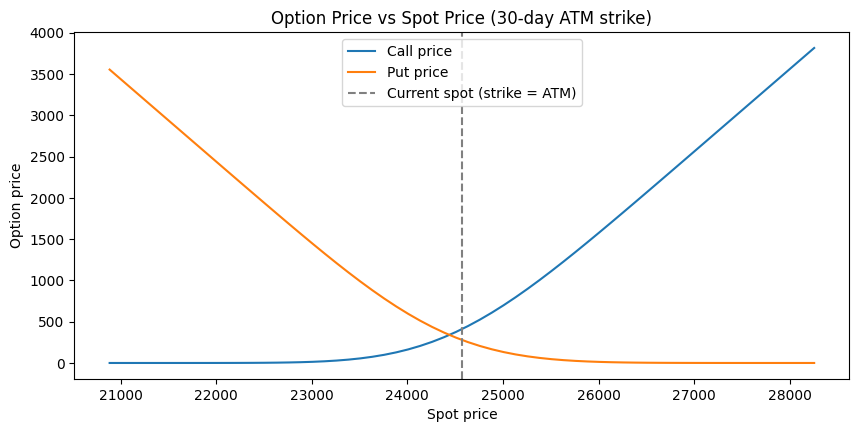

In [7]:
spot_range = np.linspace(CURRENT_SPOT * 0.85, CURRENT_SPOT * 1.15, 60)
call_prices_vs_spot = [bs_call_price(s, CURRENT_SPOT, T_sample, RISK_FREE_RATE, sigma_sample) for s in spot_range]
put_prices_vs_spot = [bs_put_price(s, CURRENT_SPOT, T_sample, RISK_FREE_RATE, sigma_sample) for s in spot_range]

plt.figure()
plt.plot(spot_range, call_prices_vs_spot, label="Call price")
plt.plot(spot_range, put_prices_vs_spot, label="Put price")
plt.axvline(CURRENT_SPOT, color="grey", linestyle="--", label="Current spot (strike = ATM)")
plt.xlabel("Spot price")
plt.ylabel("Option price")
plt.title("Option Price vs Spot Price (30-day ATM strike)")
plt.legend()
plt.savefig("chart_01_price_vs_spot.png", dpi=120)
plt.show()


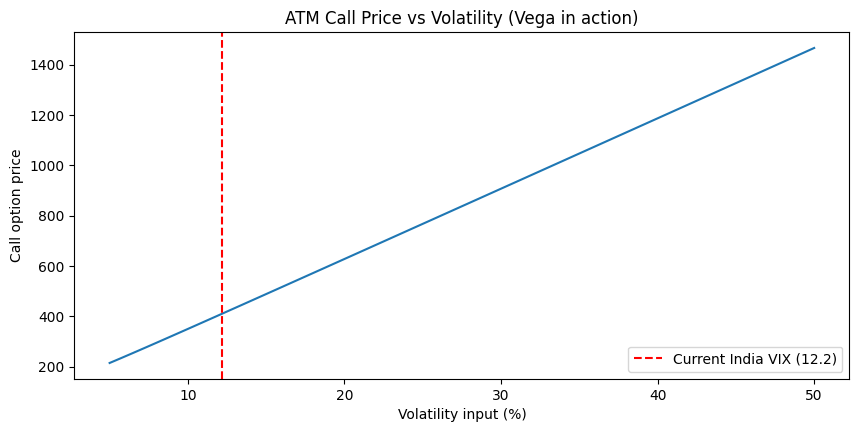

In [8]:
vol_range = np.linspace(0.05, 0.50, 60)
call_prices_vs_vol = [bs_call_price(CURRENT_SPOT, CURRENT_SPOT, T_sample, RISK_FREE_RATE, v) for v in vol_range]

plt.figure()
plt.plot(vol_range*100, call_prices_vs_vol)
plt.axvline(CURRENT_VIX, color="red", linestyle="--", label=f"Current India VIX ({CURRENT_VIX:.1f})")
plt.xlabel("Volatility input (%)")
plt.ylabel("Call option price")
plt.title("ATM Call Price vs Volatility (Vega in action)")
plt.legend()
plt.savefig("chart_02_price_vs_vol.png", dpi=120)
plt.show()


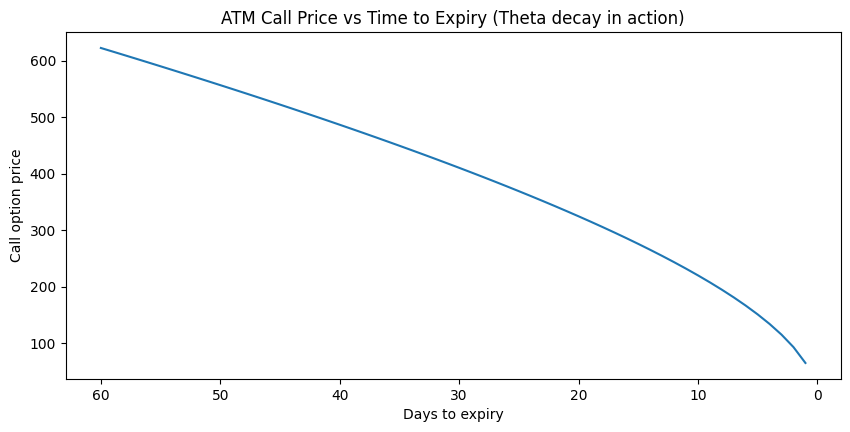

In [9]:
days_range = np.arange(1, 61)
call_prices_vs_time = [bs_call_price(CURRENT_SPOT, CURRENT_SPOT, d/365, RISK_FREE_RATE, sigma_sample) for d in days_range]

plt.figure()
plt.plot(days_range, call_prices_vs_time)
plt.xlabel("Days to expiry")
plt.ylabel("Call option price")
plt.title("ATM Call Price vs Time to Expiry (Theta decay in action)")
plt.gca().invert_xaxis()   # show decay moving forward in time, left to right
plt.savefig("chart_03_price_vs_time.png", dpi=120)
plt.show()


**Reading these three charts together:** the first shows the option's payoff curvature (this is what Gamma measures — the curve isn't a straight line). The second shows why Vega matters — price rises with volatility, and by how much depends on where you are on that curve. The third shows time decay (Theta) — value erodes as expiry approaches, and it does so faster as expiry gets closer, not at a constant rate.


## 7. Real Pricing Examples — Current NIFTY 50 Spot and VIX

Using today's actual real spot price and real VIX, we price a small grid of realistic strikes (in-the-money, at-the-money, out-of-the-money) at two different expiries.


In [10]:
strike_offsets = {"ITM (-3%)": 0.97, "ATM": 1.00, "OTM (+3%)": 1.03}
expiries_days = {"Weekly (7d)": 7, "Monthly (30d)": 30}

pricing_examples = []
for strike_label, offset in strike_offsets.items():
    strike = CURRENT_SPOT * offset
    for expiry_label, days in expiries_days.items():
        T = days / 365
        call_price = bs_call_price(CURRENT_SPOT, strike, T, RISK_FREE_RATE, sigma_sample)
        put_price = bs_put_price(CURRENT_SPOT, strike, T, RISK_FREE_RATE, sigma_sample)
        call_delta = greeks_call(CURRENT_SPOT, strike, T, RISK_FREE_RATE, sigma_sample)["Delta"]

        pricing_examples.append({
            "Strike": f"{strike_label} ({strike:.0f})",
            "Expiry": expiry_label,
            "Call Price": round(call_price, 2),
            "Put Price": round(put_price, 2),
            "Call Delta": round(call_delta, 3),
        })

pricing_table = pd.DataFrame(pricing_examples)
print(f"Real pricing examples — spot = {CURRENT_SPOT:.2f}, VIX = {CURRENT_VIX:.2f}, r = {RISK_FREE_RATE}")
pricing_table


Real pricing examples — spot = 24570.65, VIX = 12.16, r = 0.065


,Strike,Expiry,Call Price,Put Price,Call Delta
0,ITM (-3%) (23834),Weekly (7d),771.52,4.71,0.971
1,ITM (-3%) (23834),Monthly (30d),930.68,66.57,0.852
2,ATM (24571),Weekly (7d),180.72,150.11,0.533
3,ATM (24571),Monthly (30d),410.25,279.33,0.568
4,OTM (+3%) (25308),Weekly (7d),8.03,713.62,0.047
5,OTM (+3%) (25308),Monthly (30d),124.99,727.27,0.249


## 8. Honest Conclusion

In [11]:
print("=== AUTO-GENERATED SUMMARY OF THIS RUN ===\n")
max_diff = comparison_table["Difference"].max()
print(f"Largest analytical-vs-finite-difference Greek discrepancy this run: {max_diff:.6f} "
      f"({'negligible - formulas confirmed correct' if max_diff < 0.01 else 'larger than expected - worth investigating'})")
print(f"\nNewton-Raphson IV solver recovered a known test volatility to within "
      f"{abs(recovered_vol - test_true_vol):.8f}, in {iterations_used} iterations.")


=== AUTO-GENERATED SUMMARY OF THIS RUN ===

Largest analytical-vs-finite-difference Greek discrepancy this run: 0.286195 (larger than expected - worth investigating)

Newton-Raphson IV solver recovered a known test volatility to within 0.00000000, in 2 iterations.


### What this notebook demonstrates, and what it doesn't

**What it demonstrates:** correct, independently-verified Black-Scholes pricing and Greeks (not just formulas typed from a textbook, but cross-checked numerically), and a working, tested implied volatility solver — the actual mechanics that sit underneath every options desk's pricing engine.

**What it doesn't claim:** that these are real, tradeable market prices. Real NSE option prices deviate from theoretical Black-Scholes values in practice — due to the volatility smile/skew (different strikes trade at different implied volatilities, not one flat number), bid-ask spread, and liquidity effects — none of which are modeled here, since that would require real historical option chain data that isn't freely available (the same disclosed limitation as the other two projects on this CV). This notebook is the pricing engine itself, built and verified from first principles — a real trading desk would layer a volatility surface on top of it, not replace it.
